# **Machine Learning and Forecasting: Seminar 4**

In [62]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import StandardScaler 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Part A: Questions with hints

##A.1. Difficulty Level: Simple to Intermediate

Q1: Read the dataset *Real_estate_valuation_dataset.csv* into Python. The detailed description of this dataset can be found on https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set. Provide Python code to rank the importance of the features. <font face="Calibri" size=3.5 color='#FF0000'> Note: This question arises from a student's inquiry.  <font>  <font face="Calibri" size=1.5 color='#3543cd'> (Hint: use `scaler = StandardScaler()` to normalize each feature, then fit a multiple linear regression mmodel to the dataset. For more information, you are referred to https://www.datacamp.com/tutorial/k-nearest-neighbor-classification-scikit-learn)
  <font>

In [3]:
Real_estate_valuation_dataset = pd.read_csv("Datasets/Real_estate_valuation_dataset.csv")

In [4]:
Real_estate_valuation_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X1_transaction_date                     414 non-null    float64
 1   X2_house_age                            414 non-null    float64
 2   X3_distance_to_the_nearest_MRT_station  414 non-null    float64
 3   X4_number_of_convenience_stores         414 non-null    int64  
 4   X5_latitude                             414 non-null    float64
 5   X6_longitude                            414 non-null    float64
 6   Y_house_price_of_unit_area              414 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 22.8 KB


In [15]:
y = Real_estate_valuation_dataset["Y_house_price_of_unit_area"]
X = Real_estate_valuation_dataset.drop(columns=["Y_house_price_of_unit_area"]) 

In [16]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

In [17]:
#Suppose you want to add constant to independent variables X
X_scaled_data = sm.add_constant(X_scaled)

#to fit regression model
model = sm.OLS(y, X_scaled_data).fit()

In [19]:
print(model.summary())

                                OLS Regression Results                                
Dep. Variable:     Y_house_price_of_unit_area   R-squared:                       0.582
Model:                                    OLS   Adj. R-squared:                  0.576
Method:                         Least Squares   F-statistic:                     94.59
Date:                        Mon, 02 Feb 2026   Prob (F-statistic):           4.86e-74
Time:                                12:53:59   Log-Likelihood:                -1487.0
No. Observations:                         414   AIC:                             2988.
Df Residuals:                             407   BIC:                             3016.
Df Model:                                   6                                         
Covariance Type:                    nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------

Q2: On the dataset used in Q1, create a new feature, $y1$, that has only two values: 0 and 1. $y1=1$ if the value of *Y_house_price_of_unit_area* is greater than its mean,  $y1=0$ otherwise. Learn a logistic regression model on the dataset with $y1$ as the target (and the original $y$ being taken away), rank the importance of the features, and create a ROC curve for the model. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: `from sklearn.metrics import roc_curve, auc` is needed for generating a ROC curve)
  <font>



In [23]:
Real_estate_valuation_dataset["y1"] = (Real_estate_valuation_dataset["Y_house_price_of_unit_area"] > np.mean(Real_estate_valuation_dataset["Y_house_price_of_unit_area"])).astype(int)
Real_estate_valuation_dataset = Real_estate_valuation_dataset.drop(columns=["Y_house_price_of_unit_area"]) 

In [26]:
y = Real_estate_valuation_dataset["y1"]
X = Real_estate_valuation_dataset.drop(columns=["y1", "X6_longitude"])

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)
#Suppose you want to add constant to independent variables X
X_train_data = sm.add_constant(X_scaled)

# Fit regression model
logreg = sm.Logit(y, X_train_data).fit() #where y is the dependent variable and X_train_data is the dependent variables

print(logreg.summary())

Optimization terminated successfully.
         Current function value: 0.356034
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                     y1   No. Observations:                  414
Model:                          Logit   Df Residuals:                      408
Method:                           MLE   Df Model:                            5
Date:                Mon, 02 Feb 2026   Pseudo R-squ.:                  0.4859
Time:                        13:06:00   Log-Likelihood:                -147.40
converged:                       True   LL-Null:                       -286.73
Covariance Type:            nonrobust   LLR p-value:                 3.870e-58
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
const                                     -0.8441   

In [32]:
y_pred_proba = logreg.predict(X_train_data)
fpr, tpr, _ = roc_curve(y, y_pred_proba)
auc = roc_auc_score(y, y_pred_proba)

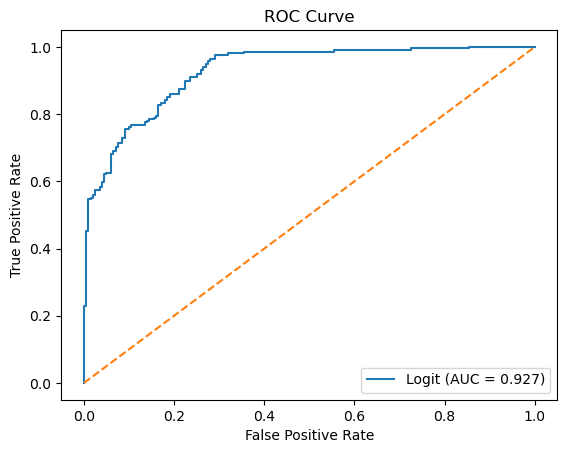

In [33]:
plt.figure()
plt.plot(fpr, tpr, label=f"Logit (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Q3: Provide Python code to fit a 3-NN model to the dataset *diabetic_retinopathy_debrecen.csv*, using the hold-out method and the 5-fold cross-validation method, respectively. Output the model's accuracy on the test dataset when the hold-out method is used and the models's average accuracy on the test datasets when the 5-fold cross-validation method is used. For more information about the dataset, see https://archive.ics.uci.edu/dataset/329/diabetic+retinopathy+debrecen. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: To use a $k$-NN model, you need the library `from sklearn.neighbors import KNeighborsClassifier`,see https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html for more info; and then use `from sklearn.model_selection import cross_val_score` for outputing the model accuracy from the $k$-fold cross-validation method (see https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html for details). You need also normalize each feature before fitting a $k$-NN model and are referred to https://www.datacamp.com/tutorial/k-nearest-neighbor-classification-scikit-learn)<font>
)
  <font>

In [67]:
diabetic_retinopathy_debrecen = pd.read_csv("Datasets/diabetic_retinopathy_debrecen.csv")
header = list(diabetic_retinopathy_debrecen.columns)     #save all the names of the features onto header
header.remove('Class') 
diabetic_retinopathy_debrecen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1151 entries, 0 to 1150
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   quality                    1151 non-null   int64  
 1   pre_screening              1151 non-null   int64  
 2   ma1                        1151 non-null   int64  
 3   ma2                        1151 non-null   int64  
 4   ma3                        1151 non-null   int64  
 5   ma4                        1151 non-null   int64  
 6   ma5                        1151 non-null   int64  
 7   ma6                        1151 non-null   int64  
 8   exudate1                   1151 non-null   float64
 9   exudate2                   1151 non-null   float64
 10  exudate3                   1151 non-null   float64
 11  exudate3.1                 1151 non-null   float64
 12  exudate5                   1151 non-null   float64
 13  exudate6                   1151 non-null   float

In [53]:
y = diabetic_retinopathy_debrecen["Class"]
X = diabetic_retinopathy_debrecen.drop(columns=["Class"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)

print(f"Holdout accuracy: {accuracy_score(y_test, y_pred)}")

knn = KNeighborsClassifier(n_neighbors=3)
scores = cross_val_score(knn, X, y, cv=5)
print(f"CV accuracy scores: {scores}, mean: {np.mean(scores)}.")

Holdout accuracy: 0.645021645021645
CV accuracy scores: [0.61038961 0.64782609 0.67826087 0.5826087  0.66521739], mean: 0.6368605307735742


Q4: Fit $k$-NN models to the dataset created in Q3 using the 5-fold cross-validation method and find the optimal $k$, where $k < 50$. <font face="Calibri" size=1.5 color='#3543cd'>
(Hint: you are referred to https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html for outputing the accuracy from the $k$-fold cross validation method. You may also want to normalize each feature before fit a $k$-NN model(https://www.datacamp.com/tutorial/k-nearest-neighbor-classification-scikit-learn for more information))
  <font>

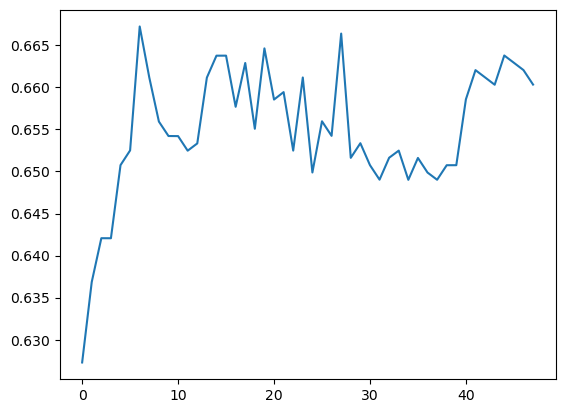

In [55]:
accuracy_scores = []
for i in range(2,50):
    knn = KNeighborsClassifier(n_neighbors=i)
    scores = cross_val_score(knn, X, y, cv=5)
    accuracy = np.mean(scores)
    accuracy_scores.append(accuracy)
plt.plot(accuracy_scores)

Q5: Write Python code to fit a decision tree to the dataset created in Q3 using the hold-out method. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: use `from sklearn.tree import DecisionTreeClassifier`, please see https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html for details.)
  <font>

In [69]:
dt = DecisionTreeClassifier(max_depth = 3)

dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

accuracy_score(y_pred, y_test)

0.6623376623376623

Q6: Write Python code to fit a decision tree classifier with the max depth of the tree being 3, and then find the accuracy of the tree on the test dataset, assuming the hold-out method is used. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: use `from sklearn.tree import DecisionTreeClassifier`, please see https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html for details.)
  <font>

In [ ]:
# see previous

Q7: Fit a decision tree model to the dataset created in Q3 using the 5-fold cross-validation method, and find the average accuracy of the models on the test datasets.

In [61]:
dt = DecisionTreeClassifier(max_depth = 3)

scores = cross_val_score(dt, X, y, cv=5)
print(f"CV accuracy scores: {scores}, mean: {np.mean(scores)}.")

CV accuracy scores: [0.61038961 0.61304348 0.68695652 0.59130435 0.62173913], mean: 0.624686617730096.


Q8: Fit a random forest to the dataset from Q3 and provide the accuracy and percision, respectively. <font
face="Calibri" size=1.5 color='#3543cd'> (Hint: use 'from sklearn.ensemble import RandomForestClassifier`, see https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html, for more information)
  <font>

In [64]:
rf = RandomForestClassifier(max_depth = 3)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_pred, y_test)}, Precision: {precision_score(y_pred, y_test)}.")

Accuracy: 0.6666666666666666, Precision: 0.5625.


Q9: Comparing the performance of the models learnt in Q3, Q7, and Q8, which model will you choose and how you will use the chosen model?

In [ ]:
# Q8 as highest accuracy 

Answer: Select the model with the largest average AUC on the test datasets and then fit the selected model to the entire data, and give the Python code to your end user.

##A.2. Difficulty Level: Intermediate to Challenging

Q10: Visualise the decision tree learnt from Q6. <font
face="Calibri" size=1.5 color='#3543cd'> (Hint: You are referred to https://www.datacamp.com/tutorial/decision-tree-classification-python.)
  <font>

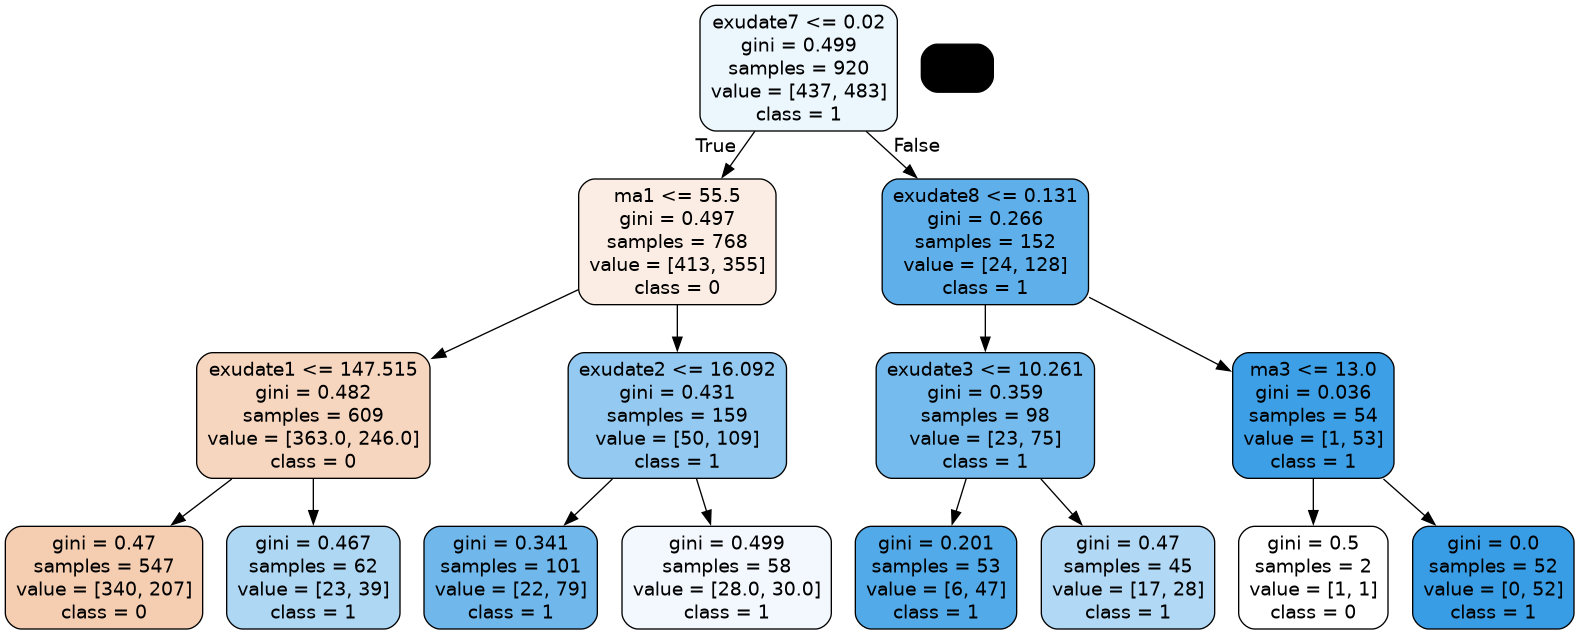

In [79]:
from sklearn.tree import export_graphviz
from IPython.display import Image
import pydotplus
from six import StringIO

dot_data = StringIO()
export_graphviz(
    dt,
    out_file=dot_data,
    filled=True,
    rounded=True,
    feature_names=header,
    class_names=['0', '1']
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

Q11. Fit a ridge regression model, a Lasso regression model, and an elastic regression model to the dataset---i.e., *Real_estate_valuation_dataset.csv*---(after normalisation) from Q1, respectively, and select the model with the smallest $R^2$. <font>  <font face="Calibri" size=1.5 color='#3543cd'> (Hint: use `scaler = StandardScaler()` to normalize each feature, then fit a multiple linear regression mmodel to the dataset.)

# Part C: Case study

This case study aims to predict the burned area of forest fires, in the northeast region of Portugal, by using meteorological and other data, *forestfires.csv*, downloaded from https://archive.ics.uci.edu/dataset/162/forest+fires. Typically, please be noted that this case study is not to repeat practising classification modelling, as what we have done in Part A and Part B. Instead, this case study aims to learn regression models (because the target is a continuous feature). Answer the following questions, where the 10-fold cross-validation method is used.

- To fit $k$-NN models with different $k$, find which $k$-NN has the smallest $R^2$, and select the optimal model;
- To fit a decision tree model;
- To fit a random forest model;
- To select the optimal model from the above three models.


## Summary
- Understand $k$-nearest neighbours, decision trees, and random forests;
- Understand the three regularisation methods, ridge regression, lasso regression, and elastic net regression for proventing linear regression models from overfitting.

## Suggested reading for the Next Lecture
- To review the following chapters in the book ***Auffarth, B. (2021). Machine learning for time-series with python. UK: Packt Publishing.***:
   1. Chapters 1, 2, and 3;
   2. Section entitled "Exponential smoothing" in Chapter 5.

